# Task 1 — Futures Market & Contract Analysis

This notebook establishes the market and contract-level foundation for a systematic
futures trend-following study. The primary focus is on **CBOT Soybeans (SY)**,
with **SHFE Gold (AUG)** serving as the main secondary market for cross-market
validation.

The analysis connects contract mechanics, transaction costs, market structure,
and long-run price behavior to the statistical tests and trading-strategy
experiments developed in the subsequent notebooks.

For each market, we examine:

* Exchange and ticker conventions (TickData, Bloomberg, and local Chinese tickers)
* Contract size and approximate contract value
* Point value (PV) — the cash value of one full price-unit movement
* Minimum tick size and tick value
* Trading hours and exchange-local timestamps
* Quote currency
* Round-turn transaction cost (`Slpg`)
* Key economic and market drivers that may contribute to persistent price movements

Contract specifications are obtained from the reference files provided on CourseWorks:

* `data/TF Data.xls` — global futures contract table
* `data/TrCostsChina 03-07-2019.xls` — Chinese futures contract and transaction-cost table

In addition to SY and AUG, several other secondary markets are included for broader
market comparison and visual inspection.

| Role | TickData | Description |
|---|---|---|
| **Primary** | **SY** | CBOT Soybeans |
| **Main secondary** | **AUG** | SHFE Gold |
| Additional comparison | BTC | CME Bitcoin |
| Additional comparison | CFC | ZCE Cotton No.1 |
| Additional comparison | COKE | DCE Coke |
| Additional comparison | CS | DCE Corn Starch |
| Additional comparison | CUC | SHFE Copper Cathode |
| Additional comparison | SOYBN | DCE No.1 Soybeans |

The price-series inspection in this notebook is descriptive. Formal evidence on
trend-following versus mean-reversion behavior, together with the approximate
time-scales of any detected inefficiency, is evaluated later using the
**Variance-Ratio** and **Push-Response** tests.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}' if isinstance(x, float) else str(x))
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)

DATA = Path('data')
print('Data dir:', DATA.resolve())
print('Files:', sorted(p.name for p in DATA.iterdir() if p.is_file()))

Data dir: /Users/apple/Desktop/期货市场趋势跟踪策略的量化分析与滚动回测/数据/data
Files: ['.DS_Store', 'AUG-5minHLV.csv', 'BTC-5minHLV.csv', 'CFC-5minHLV.csv', 'COKE-5minHLV.csv', 'CS-5minHLV.csv', 'CUC-5minHLV.csv', 'SOYBN-5minHLV.csv', 'SY-5minHLV.csv', 'TF Data.xls', 'TrCostsChina 03-07-2019.xls']


# 1. Loading the contract-spec reference tables

`TF Data.xls` provides the global futures contract reference table. The main fields used in this project are:

* `TickData`, `Bloomberg` — ticker conventions
* `Description`, `Exchange`, `Currency`
* `Contract Value`, `Point Value`, `Tick Value`
* `Time Open`, `Time Close` — exchange-local trading-session information
* `Slpg` — suggested full round-turn transaction cost

For the primary market, **CBOT Soybeans (SY)**, the relevant contract specifications and transaction-cost parameters are obtained from this reference table.

`TrCostsChina 03-07-2019.xls` (sheet `TrCostsChina2`) provides the corresponding reference information for the Chinese futures markets. Following the project instructions, the two key parameters required from this table are:

* `Slpg` — full round-turn transaction cost, expressed in CNY
* `PV` — point value, expressed in CNY per full price-unit movement

Other contract information is retained for market description and cross-checking where appropriate.

In [2]:
tf = pd.read_excel(DATA / 'TF Data.xls', sheet_name='TF Data', header=2)
# drop helper / blank columns
tf = tf.loc[:, ~tf.columns.astype(str).str.startswith('Unnamed')]
print('TF Data shape:', tf.shape)
tf[['TickData','Bloomberg','Description','Exchange','Currency',
    'Contract Value','Point Value','Tick Value','Time Open','Time Close','Slpg']].head()

TF Data shape: (64, 27)


,TickData,Bloomberg,Description,Exchange,Currency,Contract Value,Point Value,Tick Value,Time Open,Time Close,Slpg
0,AD,AD,Australian Dollar,CME,USD,"71,810.0000",1000,10.0000,07:20:00,14:00:00,24.0000
1,BN,RX,EURO Bund (f.k.a. as German Bund),EUREX,EUR,"164,640.0000",1000,10.0000,08:00:00,18:00:00,18.0000
2,BO,BO,SoyBean Oil,CBOT-CME,USD,"17,370.0000",600,6.0000,09:30:00,13:15:00,39.0000
3,BP,BP,British Pound,CME,USD,"81,950.0000",625,6.2500,07:20:00,14:00:00,28.0000
4,BZ,DU,"Schatz, German 2-year Notes",EUREX,EUR,"111,885.0000",1000,5.0000,08:00:00,18:00:00,10.5000


In [3]:
cn = pd.read_excel(DATA / 'TrCostsChina 03-07-2019.xls',
                   sheet_name='TrCostsChina2', header=0)
cn = cn.dropna(subset=['Chinese Ticker']).reset_index(drop=True)
print('China table shape:', cn.shape)
cn[['Chinese Ticker','TD','BB','Name','Slpg','PV','Margin',
    'TimeStart','TimeEnd']].head()

China table shape: (40, 21)


,Chinese Ticker,TD,BB,Name,Slpg,PV,Margin,TimeStart,TimeEnd
0,IC,NaN,FFD,CSI 500 IDX,0.3250,200.0000,"328,212.0000",09:30:00,15:00:00
1,IF,NaN,IFB,CSI 300 IDX,0.2167,300.0000,"229,344.0000",09:30:00,15:00:00
2,IH,NaN,FFB,SSE 50 Index,0.2167,300.0000,"168,132.0000",09:30:00,15:00:00
3,T,NaN,TFT,China 10yr Bond,0.0065,"10,000.0000","19,527.0000",09:30:00,15:00:00
4,AL,ALA,AA,SHFE Aluminium,13.0000,5.0000,"4,725.0000",09:00:00,15:00:00


## 2. Primary market — **SY (CBOT Soybeans)**

### 2.1 Contract specifications

In [4]:
sy = tf[tf['TickData'] == 'SY'].iloc[0]
sy_spec = pd.Series({
    'TickData ticker'     : sy['TickData'],
    'Bloomberg ticker'    : sy['Bloomberg'],
    'Description'         : sy['Description'],
    'Exchange'            : sy['Exchange'],
    'Quote currency'      : sy['Currency'],
    'Contract size'       : '5,000 bushels',
    'Contract value (USD)': sy['Contract Value'],
    'Point value (USD / 1.00 price unit)': sy['Point Value'],
    'Tick value (USD / min tick)'       : sy['Tick Value'],
    'Minimum tick size (price units)'   : sy['Tick Value'] / sy['Point Value'],
    'Pit session — Chicago time'        : f"{sy['Time Open']} – {sy['Time Close']}",
    'Pit session — New York (EST)'      : f"{sy['Time Open.1']} – {sy['Time Close.1']}",
    'Round-turn slippage Slpg (USD)'    : sy['Slpg'],
    'Initial margin (USD)'              : sy['Margin'],
    'TickData history starts'           : sy['Date Start'].date(),
})
sy_spec.to_frame('Value')

,Value
TickData ticker,SY
Bloomberg ticker,S_
Description,Soy Beans
Exchange,CBOT-CME
Quote currency,USD
Contract size,"5,000 bushels"
Contract value (USD),"44,762.5000"
Point value (USD / 1.00 price unit),50
Tick value (USD / min tick),12.5000
Minimum tick size (price units),0.2500


**How to read these numbers.** Soybeans are quoted in **U.S. cents per bushel**
(e.g. `895.25`), rather than dollars per bushel. One full price point therefore
corresponds to 1 cent per bushel. With a contract size of 5,000 bushels, a
1.00-point price movement is worth **\$50 per contract**, consistent with the
`Point Value` reported above.

The minimum tick is **0.25 price units** (¼ cent per bushel), corresponding to
a tick value of **\$12.50 per contract**. The reference table indicates that no
additional ×100 or ÷100 price-scaling adjustment is required for SY.

`Slpg` represents the suggested **full round-turn transaction cost** for one
contract. For SY, the value reported in the supplied `TF Data.xls` reference
table is **\$35.50 per round turn**. How this cost is allocated across entries,
exits, and position reversals is handled explicitly in the trading-strategy
implementation.

### 2.2 Trading hours and timestamps

The reference table reports the CBOT day-session window as approximately
**09:30–13:15 Chicago time**. The timestamps in the supplied SY price file are
interpreted in exchange-local time, consistent with the project instructions.

This distinction is important because all signal construction, rolling windows,
and subsequent backtests must preserve the timing convention of the underlying
5-minute data rather than treating timestamps as if they were expressed in a
common time zone.

### 2.3 Key economic and market drivers

Several factors can contribute to persistent changes in soybean prices:

* **Planting and harvest cycles** — production expectations evolve with planting,
  growing, and harvest conditions in major producing regions.
* **Weather and crop conditions** — changes in expected yields can materially alter
  supply expectations during the growing season.
* **USDA reports** — WASDE and crop-progress releases provide new information on
  production, inventories, and demand.
* **Export demand** — international demand, particularly from major soybean
  importers, can affect the balance between available supply and expected use.
* **Crush economics** — soybean prices are linked to soybean meal and soybean oil
  through processing margins and downstream demand.
* **Macroeconomic conditions** — exchange rates, global commodity demand, and
  broader risk conditions may also influence soybean prices.

These market characteristics motivate a testable research question: **does SY exhibit
statistically detectable return dependence, and if so, is it characterized by
short-horizon mean reversion or longer-horizon persistence?** The direction,
statistical significance, and approximate time scale of this behavior are evaluated
formally using the **Variance-Ratio** and **Push-Response** tests.

### 2.4 Contract economics and round-turn P&L example

To connect the contract specifications to the later backtest, consider a long
position in **one SY contract** opened at **895.25** and closed at **910.50**.

The price change is

$$
\Delta p = 910.50 - 895.25 = 15.25
$$

price points. Since SY has a point value of **\$50 per 1.00 price-unit movement**,

$$
\text{Gross P\&L}
= \Delta p \times PV
= 15.25 \times 50
= \$762.50
$$

Equivalently, with a minimum tick size of **0.25**, the move contains

$$
\frac{15.25}{0.25} = 61
$$

ticks. At **\$12.50 per tick**,

$$
61 \times \$12.50 = \$762.50
$$

which provides a useful cross-check of the contract scaling.

The supplied reference table reports a full round-turn transaction cost of
**\$35.50**. Therefore,

$$
\text{Net P\&L}
= \$762.50 - \$35.50
= \boxed{\$727.00}
$$

| Quantity | Calculation | Value |
|---|---:|---:|
| Entry price | — | 895.25 |
| Exit price | — | 910.50 |
| Price change | `910.50 - 895.25` | 15.25 |
| Gross ticks captured | `15.25 / 0.25` | 61 |
| Gross P&L | `15.25 × 50` | \$762.50 |
| Full round-turn cost | `Slpg` | −\$35.50 |
| **Net P&L** | `762.50 - 35.50` | **\$727.00** |
| Cost in tick equivalents | `35.50 / 12.50` | **2.84 ticks** |

#### Notional exposure and margin

At an entry price of 895.25 cents per bushel, the approximate contract notional is

$$
5{,}000 \times \$8.9525 = \$44{,}762.50
$$

Using the **\$1,925 initial-margin figure reported in the supplied reference table**
for illustration, the corresponding notional-to-margin ratio is approximately

$$
\frac{44{,}762.50}{1{,}925} \approx 23.3\times
$$

This illustrates the embedded leverage of futures contracts. Importantly, initial
margin is collateral rather than the maximum amount of capital at risk, and margin
requirements can change over time. The ratio is therefore a contract-economics
illustration rather than a direct measure of portfolio risk.

For this example, net P&L relative to the reference initial margin is

$$
\frac{727}{1{,}925} \approx 37.8\%
$$

whereas net P&L relative to contract notional is

$$
\frac{727}{44{,}762.50} \approx 1.62\%
$$

These quantities should not be interpreted as interchangeable measures of
strategy return.

#### Transaction-cost hurdle

A completed round turn must generate enough gross price movement to offset the
full transaction cost. The one-contract breakeven movement is

$$
\Delta p_{\text{breakeven}}
= \frac{Slpg}{PV}
= \frac{35.5}{50}
= 0.71
$$

price points, equivalent to

$$
\frac{0.71}{0.25} \approx 2.84
$$

minimum ticks.

This breakeven calculation provides a useful transaction-cost benchmark for the
later strategy analysis: a trading rule must capture sufficiently large price
movements, after accounting for its turnover, to overcome this cost hurdle.

The exact allocation of transaction costs across entries, exits, and position
reversals is implemented later according to the supplied `Channel WithDDControl`
trading logic.

# 3. Secondary markets

The main secondary market in this study is **SHFE Gold (AUG)**, which is used for
cross-market validation of the statistical tests and trading-strategy framework
developed for the primary SY market.

Several additional futures markets are retained for broader comparison, including
**CME Bitcoin (BTC)** and five Chinese commodity futures: **Cotton No.1 (CFC)**,
**Coke (COKE)**, **Corn Starch (CS)**, **Copper Cathode (CUC)**, and **No.1
Soybeans (SOYBN)**.

The project materials suggest that the Chinese futures markets may exhibit
particularly strong trend-following properties. Rather than treating this as an
assumption, we use it as a **cross-market research hypothesis**: if persistent
return dependence is present, its direction and time scale should be detectable
statistically and its economic relevance should survive transaction costs and
out-of-sample testing.

For the Chinese futures contracts, monetary contract parameters such as **Point
Value (PV)** and **Slpg** are expressed in **CNY (Renminbi)** unless otherwise
stated.

In [5]:
specs = []

# BTC specifications come directly from the global TF Data reference table.
btc = tf[tf['TickData'] == 'BTC'].iloc[0]

specs.append({
    'TickData'      : 'BTC',
    'Bloomberg'     : btc['Bloomberg'],
    'Local ticker'  : '—',
    'Description'   : btc['Description'],
    'Exchange'      : btc['Exchange'],
    'Currency'      : btc['Currency'],
    'Contract size' : '5 BTC',
    'Contract value': btc['Contract Value'],
    'Point Value'   : btc['Point Value'],
    'Tick Value'    : btc['Tick Value'],
    'Min tick'      : btc['Tick Value'] / btc['Point Value'],
    'Hours (local)' : f"{btc['Time Open']}–{btc['Time Close']}",
    'Slpg'          : btc['Slpg'],
})

# Chinese-market PV and Slpg values come directly from TrCostsChina.
# Descriptive contract size and minimum tick information are retained
# separately for interpretation and unit checks.
china_map = {
    'AUG'  : {'contract': '1,000 g',  'tick': 0.05, 'desc': 'SHFE Gold',           'exchange': 'SHFE'},
    'CFC'  : {'contract': '5 tonnes', 'tick': 5.0,  'desc': 'ZCE Cotton No.1',     'exchange': 'ZCE'},
    'COKE' : {'contract': '100 t',    'tick': 0.5,  'desc': 'DCE Coke',            'exchange': 'DCE'},
    'CS'   : {'contract': '10 t',     'tick': 1.0,  'desc': 'DCE Corn Starch',     'exchange': 'DCE'},
    'CUC'  : {'contract': '5 t',      'tick': 10.0, 'desc': 'SHFE Copper Cathode', 'exchange': 'SHFE'},
    'SOYBN': {'contract': '10 t',     'tick': 1.0,  'desc': 'DCE No.1 Soybeans',   'exchange': 'DCE'},
}

for td, meta in china_map.items():
    row = cn[cn['TD'] == td].iloc[0]
    pv = row['PV']

    specs.append({
        'TickData'      : td,
        'Bloomberg'     : row['BB'],
        'Local ticker'  : row['Chinese Ticker'],
        'Description'   : meta['desc'],
        'Exchange'      : meta['exchange'],
        'Currency'      : 'CNY',
        'Contract size' : meta['contract'],
        'Contract value': np.nan,
        'Point Value'   : pv,
        'Tick Value'    : pv * meta['tick'],
        'Min tick'      : meta['tick'],
        'Hours (local)' : f"{row['TimeStart']}–{row['TimeEnd']}",
        'Slpg'          : row['Slpg'],
    })

spec_df = pd.DataFrame(specs).set_index('TickData')
spec_df

,Bloomberg,Local ticker,Description,Exchange,Currency,Contract size,Contract value,Point Value,Tick Value,Min tick,Hours (local),Slpg
TickData,,,,,,,,,,,,
BTC,BTC,—,CME Bitcoin,CME,USD,5 BTC,"260,300.0000",5.0000,5.0000,1.0000,17:00:00–16:00:00,25.0000
AUG,AUA,AU,SHFE Gold,SHFE,CNY,"1,000 g",NaN,"1,000.0000",50.0000,0.0500,09:00:00–15:00:00,0.0650
CFC,VV,CF,ZCE Cotton No.1,ZCE,CNY,5 tonnes,NaN,5.0000,25.0000,5.0000,09:00:00–15:00:00,13.0000
COKE,KEE,J,DCE Coke,DCE,CNY,100 t,NaN,100.0000,50.0000,0.5000,09:00:00–15:00:00,0.6500
CS,DCS,CS,DCE Corn Starch,DCE,CNY,10 t,NaN,10.0000,10.0000,1.0000,09:00:00–15:00:00,6.5000
CUC,CU,CU,SHFE Copper Cathode,SHFE,CNY,5 t,NaN,5.0000,50.0000,10.0000,09:00:00–15:00:00,13.0000
SOYBN,AK,A,DCE No.1 Soybeans,DCE,CNY,10 t,NaN,10.0000,10.0000,1.0000,09:00:00–15:00:00,6.5000


### 3.1 Secondary-market overview

The secondary markets span several asset classes and market structures, providing
a useful setting for cross-market robustness checks.

* **AUG — SHFE Gold (AU):** CNY/gram, 1,000 g contract, 0.05 CNY minimum tick
  (= 50 CNY per tick). Key drivers include global real yields, exchange rates,
  safe-haven demand, and domestic precious-metals flows.

* **BTC — CME Bitcoin:** USD-denominated, 5 BTC contract, 5 USD minimum tick
  (= 25 USD per tick). Price dynamics are influenced by crypto-market liquidity,
  institutional flows, macro risk appetite, and the asset's continuous global
  trading environment.

* **CFC — ZCE Cotton No.1 (CF):** CNY/tonne, 5-tonne contract, 5 CNY minimum tick
  (= 25 CNY per tick). Important drivers include weather, crop conditions, textile
  demand, inventories, and domestic agricultural policy.

* **COKE — DCE Coke (J):** CNY/tonne, 100-tonne contract, 0.5 CNY minimum tick
  (= 50 CNY per tick). Price behavior is closely linked to steel demand, coking-coal
  input costs, production constraints, and industrial policy.

* **CS — DCE Corn Starch:** CNY/tonne, 10-tonne contract, 1 CNY minimum tick
  (= 10 CNY per tick). Major drivers include corn prices, processing margins,
  seasonal demand, and inventory conditions.

* **CUC — SHFE Copper Cathode (CU):** CNY/tonne, 5-tonne contract, 10 CNY minimum tick
  (= 50 CNY per tick). Key influences include global copper prices, Chinese industrial
  activity, infrastructure demand, exchange rates, and global mine supply.

* **SOYBN — DCE No.1 Soybeans (A):** CNY/tonne, 10-tonne contract, 1 CNY minimum tick
  (= 10 CNY per tick). Drivers include domestic crop conditions, inventories,
  reserve policy, processing demand, and broader soybean-market conditions.

Among these markets, **AUG is the principal secondary market used in the later
statistical and strategy experiments**; the remaining contracts provide broader
context for comparison.

### 3.2 Structural hypotheses for persistent price behavior

Several structural features of Chinese commodity futures markets may contribute to
persistent price movements and delayed adjustment to new information:

1. **Segmented market access and capital controls.** Onshore and offshore markets are not
   perfectly integrated, which can limit the speed of cross-market arbitrage and allow relative
   pricing differences to persist.

2. **Policy-sensitive supply and demand.** Production restrictions, reserve operations,
   environmental regulation, tariffs, and other policy changes can alter expected supply-demand
   conditions over extended periods rather than through a single price adjustment.

3. **Commodity-specific industrial linkages.** Markets such as copper, coke, cotton, and
   agricultural futures are tied closely to physical inventories, processing margins, and
   downstream demand. Changes in these fundamentals can evolve gradually and generate
   multi-session price adjustments.

4. **Exchange microstructure.** Trading-session breaks, daily price limits, and differences in
   market participation can affect how information is incorporated into prices across sessions.

These mechanisms provide plausible economic explanations for return persistence, but they
should be treated as **hypotheses rather than assumptions**. The project therefore tests for
trend-following versus mean-reverting behavior directly using the Variance-Ratio and
Push-Response methods before evaluating whether a channel-breakout strategy can exploit any
detected persistence after transaction costs.

## 4. Consolidated spec table (for later use in the back-test)

The columns *PV* (point value, local currency) and *Slpg* (round-turn cost, local
currency) are the two numbers the trading simulator will consume.  For USD markets
(SY, BTC) they are already in USD; for Chinese markets they are in CNY and must
either be multiplied by an FX rate at back-test time or kept in CNY throughout and
compared only in CNY terms.

In [7]:
# Consolidated contract-specification table
# -----------------------------------------
# Build the backtest reference table directly from the validated
# contract specifications above rather than manually re-entering values.

primary_row = pd.DataFrame([{
    'Market'       : 'SY',
    'Role'         : 'Primary',
    'Description'  : sy['Description'],
    'Exchange'     : sy['Exchange'],
    'Currency'     : sy['Currency'],
    'Point Value'  : sy['Point Value'],
    'Min Tick'     : sy['Tick Value'] / sy['Point Value'],
    'Tick Value'   : sy['Tick Value'],
    'Slpg'         : sy['Slpg'],
}])

secondary_rows = (
    spec_df
    .reset_index()
    .rename(columns={'TickData': 'Market'})
)

# spec_df also contains BTC and the Chinese comparison markets.
secondary_rows['Role'] = np.where(
    secondary_rows['Market'].eq('AUG'),
    'Main secondary',
    'Additional comparison'
)

secondary_rows = secondary_rows[
    [
        'Market',
        'Role',
        'Description',
        'Exchange',
        'Currency',
        'Point Value',
        'Min tick',
        'Tick Value',
        'Slpg',
    ]
].rename(columns={'Min tick': 'Min Tick'})

contract_summary = pd.concat(
    [primary_row, secondary_rows],
    ignore_index=True
)

contract_summary

,Market,Role,Description,Exchange,Currency,Point Value,Min Tick,Tick Value,Slpg
0,SY,Primary,Soy Beans,CBOT-CME,USD,50.0000,0.2500,12.5000,35.5000
1,BTC,Additional comparison,CME Bitcoin,CME,USD,5.0000,1.0000,5.0000,25.0000
2,AUG,Main secondary,SHFE Gold,SHFE,CNY,"1,000.0000",0.0500,50.0000,0.0650
3,CFC,Additional comparison,ZCE Cotton No.1,ZCE,CNY,5.0000,5.0000,25.0000,13.0000
4,COKE,Additional comparison,DCE Coke,DCE,CNY,100.0000,0.5000,50.0000,0.6500
5,CS,Additional comparison,DCE Corn Starch,DCE,CNY,10.0000,1.0000,10.0000,6.5000
6,CUC,Additional comparison,SHFE Copper Cathode,SHFE,CNY,5.0000,10.0000,50.0000,13.0000
7,SOYBN,Additional comparison,DCE No.1 Soybeans,DCE,CNY,10.0000,1.0000,10.0000,6.5000


### Trading hours and timestamp conventions

Trading-session structure matters for intraday futures research because scheduled
breaks, overnight gaps, and exchange-local timestamps can otherwise be mistaken
for missing observations.

The supplied project data use **exchange-local timestamps**. Each market is therefore
analyzed on its own local timeline unless an explicit cross-market alignment is required.

| TickData | Exchange / local time | Reference session structure | Data-handling implication |
|---|---|---|---|
| **SY** | CBOT-CME / Chicago time | Day session approximately **09:30–13:15 CT** | The supplied SY file primarily reflects the day-session structure; overnight and weekend gaps should not be interpreted as missing 5-minute bars. |
| **AUG** | SHFE / Shanghai time | Chinese futures trading includes scheduled day-session breaks and may also include night trading depending on contract and sample period | Session coverage should be inferred from the supplied timestamps rather than assumed from the exchange's full trading schedule. |
| **BTC** | CME / Chicago time | Near-24-hour electronic trading with scheduled maintenance breaks | Calendar and maintenance gaps should be distinguished from missing observations. |
| **CFC** | ZCE / Shanghai time | Day trading with scheduled session breaks; night-session availability may vary by contract and period | Preserve observed session boundaries in the supplied data. |
| **COKE** | DCE / Shanghai time | Day trading with scheduled breaks; historical night-session rules may vary | Do not synthetically fill scheduled gaps. |
| **CS** | DCE / Shanghai time | Primarily structured around Chinese commodity-futures trading sessions | Use the observed timestamp pattern as the operational trading calendar. |
| **CUC** | SHFE / Shanghai time | Day and night trading may both be relevant depending on the sample period | Determine actual coverage from the data before constructing intraday signals. |
| **SOYBN** | DCE / Shanghai time | Chinese agricultural-futures session structure with scheduled breaks | Preserve the observed exchange-local timeline. |

#### Practical implications for the research pipeline

1. **Preserve exchange-local timestamps.**  
   For single-market signal construction and backtesting, each series can remain on its
   own exchange-local timeline. Time-zone conversion becomes necessary only when markets
   are explicitly aligned for cross-market analysis.

2. **Do not automatically fill intraday gaps.**  
   Scheduled session breaks, overnight closures, weekends, and holidays are part of the
   market calendar rather than ordinary missing observations. Synthetic bar filling could
   create artificial prices and distort channel-breakout or return calculations.

3. **Infer actual session coverage from the data.**  
   Published exchange hours describe when a contract may trade, but the supplied historical
   files may cover only a subset of those sessions or may reflect historical changes in
   trading hours. The empirical timestamp distribution therefore takes precedence when
   determining the operational sample.

4. **Handle cross-market alignment explicitly.**  
   Chicago and Shanghai timestamps should never be compared as if they belonged to the same
   clock. Any future lead-lag or cross-market analysis should explicitly account for time
   zones, daylight-saving changes, and non-overlapping trading sessions.

These conventions are carried into the data-quality checks and later backtests so that
session structure is not mistaken for missing data or artificial return discontinuities.

## 5. Visual inspection of long-run price behavior

Before applying formal statistical tests, we inspect the long-run price histories of the
selected futures markets.

The purpose of this step is **exploratory rather than inferential**. Extended directional
episodes may motivate a trend-following hypothesis, but visual persistence alone does not
establish statistically significant return dependence or demonstrate that a trading strategy
will remain profitable after transaction costs.

For readability, the 5-minute observations are down-sampled to **daily closes**, defined as
the final observed 5-minute close for each trading date. The original intraday data remain
unchanged and are used in the subsequent statistical tests and strategy backtests.

This separation is intentional:

**visual inspection → statistical testing → strategy evaluation**

The visual analysis provides market intuition, while the Variance-Ratio and Push-Response
tests later determine whether any apparent persistence or mean reversion is statistically
detectable and at what approximate time scale.

In [8]:
FILES = {
    'SY'   : 'SY-5minHLV.csv',
    'AUG'  : 'AUG-5minHLV.csv',
    'BTC'  : 'BTC-5minHLV.csv',
    'CFC'  : 'CFC-5minHLV.csv',
    'COKE' : 'COKE-5minHLV.csv',
    'CS'   : 'CS-5minHLV.csv',
    'CUC'  : 'CUC-5minHLV.csv',
    'SOYBN': 'SOYBN-5minHLV.csv',
}

def load_daily_close(filename):
    """
    Load raw 5-minute prices for descriptive visualization only
    and extract the final observed close for each trading date.

    Formal data cleaning is handled separately in Task 2.
    """
    df = pd.read_csv(
        DATA / filename,
        usecols=['Date', 'Time', 'Close']
    )

    df['ts'] = pd.to_datetime(
        df['Date'] + ' ' + df['Time'],
        format='%m/%d/%Y %H:%M'
    )

    df = (
        df.sort_values('ts')
          .drop_duplicates(subset='ts', keep='last')
    )

    daily = (
        df.set_index('ts')['Close']
          .resample('D')
          .last()
          .dropna()
    )

    return daily


series = {
    ticker: load_daily_close(filename)
    for ticker, filename in FILES.items()
}

coverage = pd.DataFrame({
    ticker: {
        'Start': s.index.min().date(),
        'End': s.index.max().date(),
        'Trading days': len(s)
    }
    for ticker, s in series.items()
}).T

coverage

,Start,End,Trading days
SY,1982-07-01,2026-04-10,11037
AUG,2018-05-03,2026-04-10,1927
BTC,2017-12-18,2026-04-10,2588
CFC,2018-05-03,2026-04-10,1927
COKE,2018-05-03,2026-04-10,1927
CS,2018-05-03,2026-04-10,1927
CUC,2018-05-03,2026-04-10,1927
SOYBN,2018-05-03,2026-04-10,1927


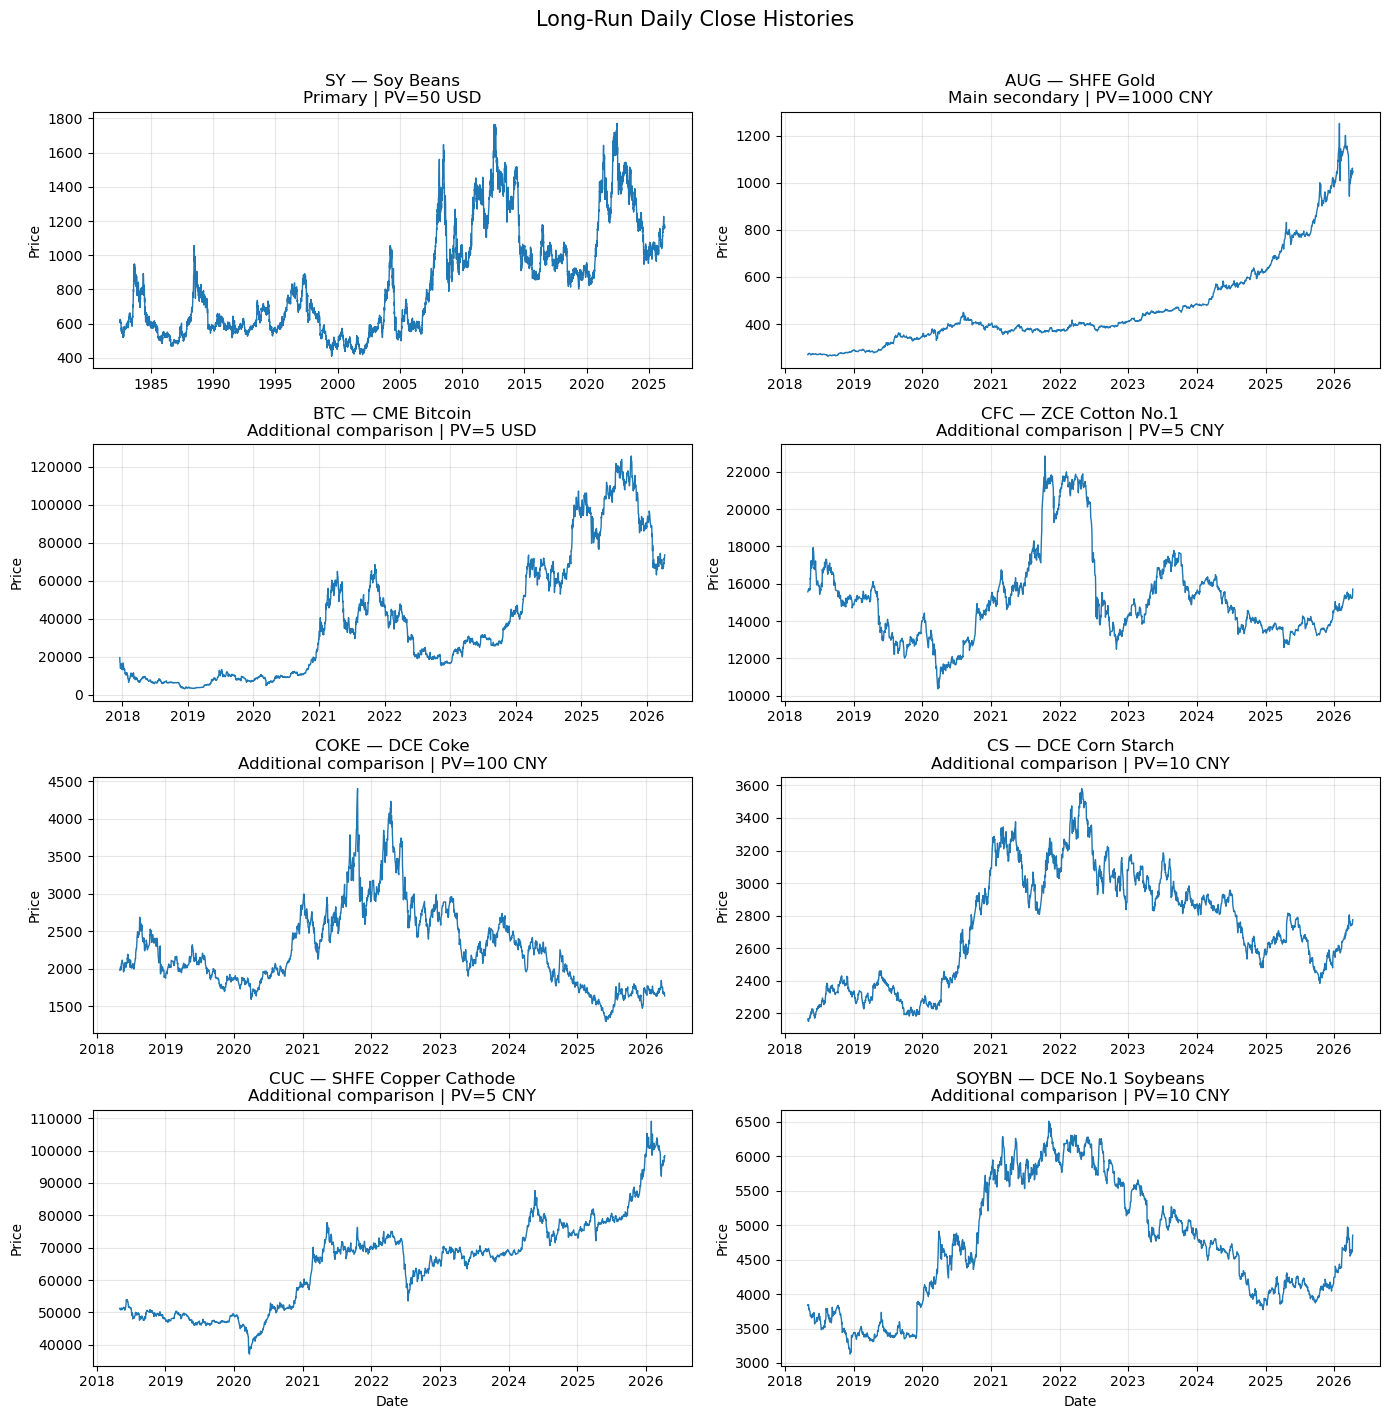

In [9]:
# Long-run daily-close overview across all selected markets

market_meta = contract_summary.set_index('Market')

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, (ticker, s) in zip(axes, series.items()):

    meta = market_meta.loc[ticker]

    ax.plot(
        s.index,
        s.values,
        linewidth=1.0
    )

    ax.set_title(
        f'{ticker} — {meta["Description"]}\n'
        f'{meta["Role"]} | PV={meta["Point Value"]:g} {meta["Currency"]}'
    )

    ax.set_ylabel('Price')
    ax.grid(alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel('Date')

fig.suptitle(
    'Long-Run Daily Close Histories',
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

### 5.1 What do the price histories suggest?

The long-run price histories reveal substantial **heterogeneity across markets and
through time** rather than a single common pattern.

**SY** exhibits repeated multi-year expansions and contractions across its long
history, suggesting pronounced regime variation. Periods of persistent directional
movement coexist with substantial reversals and range-bound episodes.

**AUG**, the main secondary market, displays a comparatively persistent upward move
over the more recent part of the sample, particularly from 2023 onward. Whether this
visual persistence corresponds to statistically detectable momentum, however, must
be evaluated from returns rather than price levels alone.

The additional comparison markets also show distinct regimes. BTC contains large
boom-and-bust cycles; CFC and SOYBN experience substantial directional reversals;
COKE transitions from a strong 2020–2022 expansion into a prolonged decline; and
CUC shows several extended directional episodes separated by periods of
consolidation.

Two observations therefore motivate the subsequent analysis:

1. **Trend behavior appears regime-dependent.** Persistent directional moves exist,
   but they are interrupted by reversals, consolidation, and changing volatility.

2. **Visual trends are not sufficient evidence of return predictability.** Price
   levels are highly persistent by construction, so apparent trends do not establish
   that returns themselves contain exploitable serial dependence.

The next stage therefore moves from visual inspection to formal return-based
evidence using the **Variance-Ratio** and **Push-Response** tests. These tests examine
whether the observed markets exhibit statistically detectable persistence or mean
reversion and help identify the time scale at which such behavior occurs.

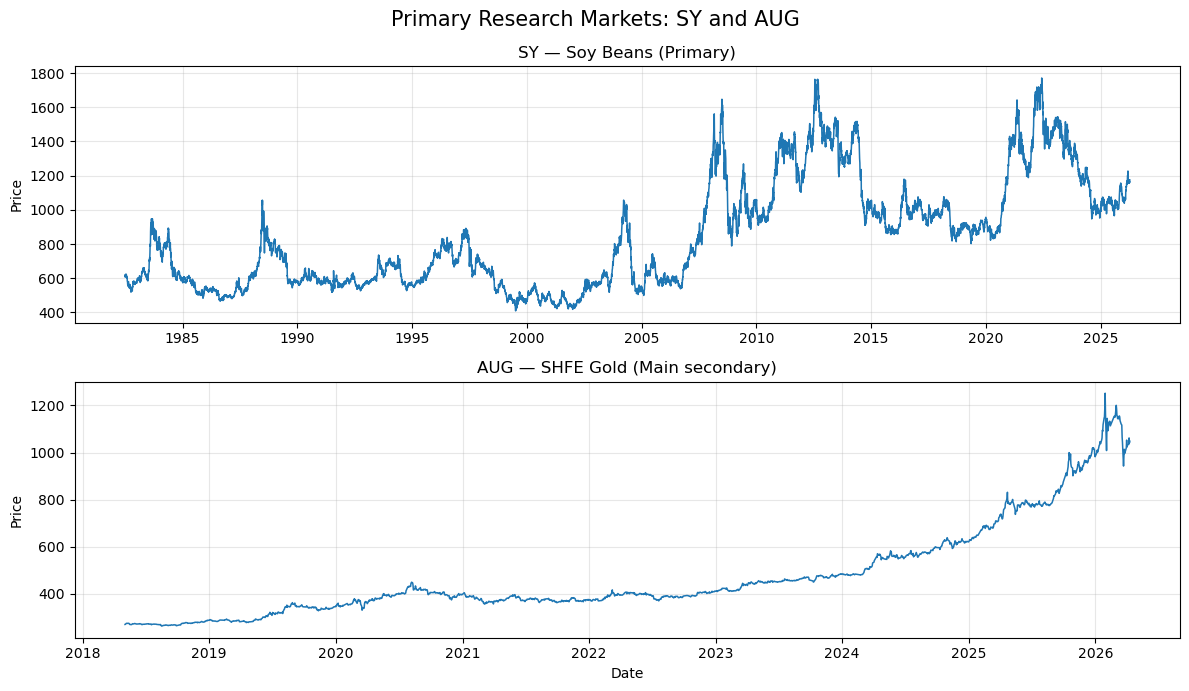

In [10]:
# Focused view of the two markets used in the main empirical analysis

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

for ax, ticker in zip(axes, ['SY', 'AUG']):
    s = series[ticker]
    meta = market_meta.loc[ticker]

    ax.plot(
        s.index,
        s.values,
        linewidth=1.1
    )

    ax.set_title(
        f'{ticker} — {meta["Description"]} '
        f'({meta["Role"]})'
    )

    ax.set_ylabel('Price')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')

fig.suptitle(
    'Primary Research Markets: SY and AUG',
    fontsize=15
)

plt.tight_layout()
plt.show()

## 6. Research takeaways

The market and contract analysis establishes several inputs for the empirical
research that follows.

**1. Contract economics must be handled market by market.**  
SY and AUG differ substantially in quotation conventions, point values, tick sizes,
currencies, transaction costs, trading sessions, and sample histories. These
differences are preserved explicitly rather than forcing the markets into a common
contract representation.

**2. Apparent price trends are heterogeneous and regime-dependent.**  
The visual evidence shows extended directional episodes, but also reversals,
consolidation, and changing volatility. This motivates trend-following research
without assuming that returns are predictably persistent.

**3. Statistical evidence must precede strategy conclusions.**  
Visual persistence in price levels does not establish exploitable serial dependence.
The next empirical stage therefore tests return behavior formally using the
Variance-Ratio and Push-Response methods, with particular attention to the direction,
statistical significance, and time scale of any detected dependence.

**4. Transaction costs create an explicit economic hurdle.**  
For SY, the supplied contract parameters imply a full round-turn cost of \$35.50,
equivalent to approximately 2.84 minimum ticks. Any trading strategy must therefore
generate sufficient gross edge relative to its turnover to remain economically
meaningful after costs.

**5. SY and AUG form the core cross-market research design.**  
SY serves as the primary long-history market, while AUG provides a structurally
different secondary market for evaluating whether the statistical findings and
strategy framework generalize across futures markets.

### Next step

**Task 2 — Data Preprocessing and Quality Control** validates the raw 5-minute
datasets, preserves genuine exchange-session gaps, checks timestamp and OHLC
consistency, and produces the cleaned datasets used by the subsequent analysis.

The cleaned SY and AUG series then feed into **Task 3 — Random-Walk Tests**, where
the visual hypotheses developed here are evaluated formally before the trading
strategy is implemented.